In [13]:
import importlib
import sys
import raman.config as config_module

def reload_all():
    for name, module in list(sys.modules.items()):
        if name.startswith("raman."):
            importlib.reload(module)
    print("Modules reloaded.")
reload_all()
config = config_module.config

Modules reloaded.


In [14]:
TRAIN_LEVEL = getattr(config, "train_level", "leaf")
USE_ALIGN_LOSS = getattr(config, "use_align_loss", True)
USE_SUPCON_LOSS = getattr(config, "use_supcon_loss", True)
ALIGN_LOSS_WEIGHT = getattr(config, "align_loss_weight", 0.05)
SUPCON_W_MAX = getattr(config, "supcon_w_max", 0.03)
SUPCON_TAU = getattr(config, "supcon_tau", 0.15)
SPLIT_LEVEL = getattr(config, "split_level", "leaf")
TRAIN_PER_PARENT = getattr(config, "train_per_parent", False)
print("\n===== Full Config Dump =====")
for k in sorted(dir(config)):
    if k.startswith("_"):
        continue
    try:
        v = getattr(config, k)
    except Exception:
        continue
    if callable(v):
        continue
    print(f"{k}: {v}")
print("\n===== Level Settings =====")
print(f"  train_level: {TRAIN_LEVEL}")
print(f"  split_level: {SPLIT_LEVEL}")
print(f"  train_per_parent: {TRAIN_PER_PARENT}")
print("==========================\n")



===== Full Config Dump =====
BAD_BANDS: [(900, 950.0)]
align_end: 50
align_loss_weight: 0.01
align_start: 20
att_pool_dropout: 0.2
axis_warp_alpha: 0.002
axis_warp_beta: 1.0
backbone_activation: relu
backbone_type: cnn
bad_bands: [(900, 950.0)]
base_width: 4
baseline_freq_max: 2.0
baseline_freq_min: 0.5
baseline_lin_max: 0.02
baseline_lin_min: 0.0
baseline_sin_max: 0.01
baseline_sin_min: 0.0
baseline_strong_amp_max: 0.15
baseline_strong_amp_min: 0.05
batch_size: 64
broad_sigma_max: 1.2
broad_sigma_min: 0.6
broad_truncate: 3.0
cardinality: 4
cosine_head: True
cosine_scale: 25
cut_max: 1800
cut_min: 600
d1_use: False
dataset_root: dataset/厌氧菌
decay_start_ratio: 0.7
delta: 1.3407821229050279
deterministic: True
early_stop_w_acc: 0.4
early_stop_w_f1: 0.6
embedding_method: tsne
encoder_type: transformer
epochs: 80
gamma: 0.8
identity_pool_kernel: 16
in_channels: 3
input_is_norm: False
label_smoothing: 0.0
learning_rate: 0.0004
lstm_bidirectional: False
lstm_dropout: 0.2
lstm_hidden: 192
ls

In [15]:
"""Raman 层级分类训练脚本。"""
import os
import random
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from datetime import datetime
import torch.nn.functional as F
import json

from raman.config import config
from raman.model import ResNeXt1D_Transformer
from raman.dataset import RamanDataset
from raman.config_io import dump_config_to_yaml
from raman.train_utils import(
    prepare_output_dirs,
    evaluate_file_level,
    get_linear_weight,
    FocalLoss,
    hierarchical_center_loss,
    SupConLoss,
    split_by_lowest_level_ratio,
    save_split_files,
    mask_logits_by_parent,
    classification_metrics
)

# ============================================================
# 手动覆盖（仅改这里，不改 config 文件）
# - 适合在 Colab 里快速单独训练某个层级/父类
# ============================================================
TRAIN_ONLY_LEVEL = "level_1"          # 例如 "level_2"
TRAIN_ONLY_PARENT_NAME = None    # 例如 "dachang"
TRAIN_ONLY_PARENT = None       # 例如 2（可选，优先级高于名称）

# 可选：覆盖损失参数（单独训练时可能不同）
OVERRIDE_ALIGN_LOSS_WEIGHT = None
OVERRIDE_SUPCON_TAU = None
OVERRIDE_SUPCON_LOSS_WEIGHT = None
# 可选：指定 SupCon 使用的层级（None 表示跟随当前训练层级）
SUPCON_LEVEL_OVERRIDE = "level_1"

# 可选：固定输出目录/时间戳，避免切换 config 导致输出分散
OVERRIDE_TIMESTAMP = None
OVERRIDE_DATASET_ROOT = None
OVERRIDE_OUTPUT_DIR = None
# ============================================================
# 应用覆盖到 config
# ============================================================
if TRAIN_ONLY_PARENT_NAME is not None:
    config.train_only_parent_name = TRAIN_ONLY_PARENT_NAME
if TRAIN_ONLY_PARENT is not None:
    config.train_only_parent = TRAIN_ONLY_PARENT
if TRAIN_ONLY_LEVEL is not None:
    config.train_only_level = TRAIN_ONLY_LEVEL

if OVERRIDE_ALIGN_LOSS_WEIGHT is not None:
    config.align_loss_weight = float(OVERRIDE_ALIGN_LOSS_WEIGHT)
if OVERRIDE_SUPCON_TAU is not None:
    config.supcon_tau = float(OVERRIDE_SUPCON_TAU)
if OVERRIDE_SUPCON_LOSS_WEIGHT is not None:
    config.supcon_loss_weight = float(OVERRIDE_SUPCON_LOSS_WEIGHT)
if SUPCON_LEVEL_OVERRIDE is not None:
    config.supcon_level = SUPCON_LEVEL_OVERRIDE

if OVERRIDE_TIMESTAMP is not None:
    config.timestamp = str(OVERRIDE_TIMESTAMP)
if OVERRIDE_OUTPUT_DIR is not None:
    config.output_dir = str(OVERRIDE_OUTPUT_DIR)
if OVERRIDE_DATASET_ROOT is not None:
    config.dataset_root = str(OVERRIDE_DATASET_ROOT)

TRAIN_LEVEL = config.train_level or "leaf"
TRAIN_PER_PARENT = config.train_per_parent

# Loss config（全局设置）
USE_ALIGN_LOSS = getattr(config, "use_align_loss", True)
USE_SUPCON_LOSS = getattr(config, "use_supcon_loss", True)
ALIGN_LOSS_WEIGHT = getattr(config, "align_loss_weight", 0.05)
SUPCON_LOSS_WEIGHT = getattr(config, "supcon_loss_weight", 0.03)
SUPCON_LEVEL = getattr(config, "supcon_level", TRAIN_LEVEL)

def set_seed(seed, deterministic=True):
    # 统一随机种子，保证可复现
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def resolve_level_order(dataset, target_level):
    # 解析训练层级顺序，并确保目标层级合法
    target_level = dataset._resolve_level_name(target_level)
    if target_level not in dataset.head_names:
        target_level = "leaf"
    level_order = []
    for name in dataset.head_names:
        level_order.append(name)
        if name == target_level:
            break
    return target_level, level_order


def _normalize_filter_values(val):
    if val is None:
        return None
    if isinstance(val, (list, tuple, set)):
        return list(val)
    return [val]


def _resolve_parent_idx_by_name(dataset, parent_level_idx, parent_name):
    if parent_name is None:
        return None
    name_to_idx = dataset.label_maps_by_level[parent_level_idx]
    return name_to_idx.get(parent_name)

def build_class_weights(level_labels, num_classes):
    # 根据当前层级标签统计类别权重（对数平滑）
    valid = level_labels >= 0
    if not valid.any():
        return np.ones(num_classes, dtype=np.float32)
    counts = np.bincount(level_labels[valid], minlength=num_classes)
    counts = np.maximum(counts, 1)
    weights = 1.0 / np.log(counts + 1.5)
    weights = weights / weights.mean()
    return weights.astype(np.float32)

def build_label_map_np(child_ids, num_classes):
    # 将全局类别 id 映射为当前子模型的局部 id
    mapping = np.full(num_classes, -1, dtype=np.int64)
    for local_idx, global_idx in enumerate(child_ids):
        mapping[int(global_idx)] = int(local_idx)
    return mapping

def evaluate_file_level_local(
    model,
    loader,
    device,
    head_index,
    label_map_tensor
):
    # 不使用父类遮罩时的单层评估（适配局部 label_map）
    model.eval()
    total_loss, total_correct, total = 0, 0, 0
    all_preds = []
    all_targets = []
    num_classes = None

    criterion_eval = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)

            if y.ndim == 2:
                y = y[:, head_index]

            if label_map_tensor is not None:
                invalid = y < 0
                y = label_map_tensor[y.clamp_min(0)]
                y[invalid] = -1

            if num_classes is None:
                num_classes = logits.size(1)

            valid = y >= 0
            if not valid.any():
                continue

            logits = logits[valid]
            y = y[valid]

            loss = criterion_eval(logits, y)

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_correct += (logits.argmax(1) == y).sum().item()
            total += bs

            all_preds.append(logits.argmax(1).detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    if num_classes is None:
        return 0.0, 0.0, {"macro_f1": 0.0, "balanced_acc": 0.0}

    y_true = np.concatenate(all_targets, axis=0)
    y_pred = np.concatenate(all_preds, axis=0)
    metrics = classification_metrics(y_true, y_pred, num_classes)

    return total_loss / max(total, 1), total_correct / max(total, 1), metrics

def main():
    # 允许外部手动指定 output_dir；未设置才自动生成
    if config.timestamp is None:
        config.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    if config.output_dir is None:
        config.output_dir = os.path.join(
            f"output_{TRAIN_LEVEL}",
            config.timestamp
        )

    # 准备输出目录（日志/模型等）
    dirs = prepare_output_dirs(config=config)

    dump_config_to_yaml(
        config,
        os.path.join(config.output_dir, "config.yaml")
    )
    log_file = open(os.path.join(dirs["logs"], "log.txt"), "w", buffering=1)
    config_log_file = open(os.path.join(dirs["logs"], "config.txt"), "w", buffering=1)

    def log(msg):
        print(msg)
        log_file.write(msg + "\n")

    def config_log(msg):
        config_log_file.write(msg + "\n")

    # 记录配置，便于复现
    config_log("===== Run Meta =====")
    config_log(f"Experiment timestamp: {config.timestamp}")
    config_log(f"Output dir: {config.output_dir}")
    config_log("=====================\n")
    config_log("===== Full Config Dump =====")

    for k in sorted(dir(config)):
        if k.startswith("_"):
            continue

        try:
            v = getattr(config, k)
        except Exception:
            continue

        if callable(v):
            continue

        config_log(f"{k}: {v}")

    # 设备与随机种子
    use_cuda = (config.use_gpu and torch.cuda.is_available())
    device = torch.device("cuda" if use_cuda else "cpu")
    log(f"Using device: {device} (config.use_gpu={config.use_gpu}, cuda_available={torch.cuda.is_available()})")
    set_seed(config.seed, deterministic=config.deterministic)
    log(f"Seed set to {config.seed} (deterministic={config.deterministic})")

    def zero_loss(feat):
        return torch.tensor(0.0, device=feat.device)

    # 构建完整 Dataset（用于全局层级/类别信息）
    full_dataset = RamanDataset(
        config.dataset_root,
        augment=False,
        config=config)

    head_names = full_dataset.head_names
    head_name_to_idx = full_dataset.head_name_to_idx
    # 解析训练层级与需要训练的层级顺序
    train_level, level_order = resolve_level_order(full_dataset, TRAIN_LEVEL)
    if train_level not in head_name_to_idx:
        raise ValueError(f"Unknown train_level: {train_level}")
    # 按指定层级进行样本级划分
    split_level = config.split_level or "leaf"

    # ============================================================
    # 样本级划分
    # - 按 split_level 分组划分
    # ============================================================
    train_idx, test_idx = split_by_lowest_level_ratio(
        full_dataset,
        lowest_level=split_level,
        train_ratio=config.train_split,
        seed=config.seed
    )

    train_idx = np.array(sorted(train_idx))
    test_idx = np.array(sorted(test_idx))

    # 保存全量切分（跨机器复现），已有则不覆盖
    from raman.train_utils import load_split_files
    existing_split = load_split_files(full_dataset, config.output_dir)
    if existing_split is None:
        save_split_files(full_dataset, train_idx, test_idx, config.output_dir)
    else:
        train_idx, test_idx = existing_split

    # ============================================================
    # 只训练指定层级/父类：简化配置（只需 level + 父类名称）
    # ============================================================
    only_level = getattr(config, "train_only_level", None)
    if only_level is not None:
        only_level = full_dataset._resolve_level_name(only_level)
    else:
        only_level = train_level

    only_parent = getattr(config, "train_only_parent", None)
    only_parent_name = getattr(config, "train_only_parent_name", None)
    if only_parent_name is not None and only_parent is None:
        parent_level = full_dataset.get_parent_level(only_level)
        if parent_level is None:
            raise ValueError(
                f"train_only_parent_name requires a parent level for {only_level}"
            )
        parent_level_idx = head_name_to_idx[parent_level]
        resolved = _resolve_parent_idx_by_name(
            full_dataset, parent_level_idx, only_parent_name
        )
        if resolved is None:
            raise ValueError(
                f"train_only_parent_name not found in {parent_level}: {only_parent_name}"
            )
        only_parent = int(resolved)
        config.train_only_parent = only_parent
        # 自动设置筛选条件（保证先切分、后筛选）
        if getattr(config, "train_filter_level", None) is None and getattr(config, "train_filter_value", None) is None:
            config.train_filter_level = parent_level
            config.train_filter_value = only_parent_name

    # ============================================================
    # 训练集筛选（先全量切分，再筛选；不影响 evalute/analysis）
    # ============================================================
    filter_level = getattr(config, "train_filter_level", None)
    filter_value = getattr(config, "train_filter_value", None)
    if filter_level and filter_value is not None:
        filter_level = full_dataset._resolve_level_name(filter_level)
        if filter_level not in head_name_to_idx:
            raise ValueError(
                f"Unknown train_filter_level: {filter_level}. Available: {head_names}"
            )
        filter_level_idx = head_name_to_idx[filter_level]
        values = _normalize_filter_values(filter_value)
        desired_ids = set()
        for v in values:
            if isinstance(v, int):
                desired_ids.add(int(v))
            else:
                idx = full_dataset.label_maps_by_level[filter_level_idx].get(str(v))
                if idx is None:
                    print(f"[Warn] train_filter_value not found in {filter_level}: {v}")
                    continue
                desired_ids.add(int(idx))

        if not desired_ids:
            raise ValueError("No valid train_filter_value found; check config.")

        labels_filter = full_dataset.level_labels[:, filter_level_idx]
        mask = np.isin(labels_filter, list(desired_ids))
        train_idx = train_idx[mask[train_idx]]
        test_idx = test_idx[mask[test_idx]]
        print(
            f"[Filter] level={filter_level}, values={values} -> "
            f"Train {len(train_idx)}, Test {len(test_idx)}"
        )

    # 统计样本分布时跟随当前训练层级（单独训练时用 only_level）
    stats_level = only_level or train_level
    stats_level_idx = head_name_to_idx[stats_level]
    labels_train_level = full_dataset.level_labels[:, stats_level_idx]

    print(f"[Sample-level Split] Train samples: {len(train_idx)}, Test samples: {len(test_idx)}")
    print(
        f"Train {stats_level} counts:",
        np.bincount(labels_train_level[train_idx][labels_train_level[train_idx] >= 0],
                   minlength=full_dataset.num_classes_by_level[stats_level])
    )
    print(
        f"Test  {stats_level} counts:",
        np.bincount(labels_train_level[test_idx][labels_train_level[test_idx] >= 0],
                   minlength=full_dataset.num_classes_by_level[stats_level])
    )

    # 构建训练/测试 Dataset（保持同一映射）
    train_dataset = RamanDataset(
        config.dataset_root,
        augment=True,
        config=config
    )
    test_dataset = RamanDataset(
        config.dataset_root,
        augment=False,
        config=config
    )

    # 决定要训练哪些层级
    if TRAIN_PER_PARENT:
        levels_to_train = level_order
    else:
        levels_to_train = [train_level]

    if only_level:
        levels_to_train = [n for n in levels_to_train if n == only_level]
        if not levels_to_train:
            raise ValueError(f"train_only_level not found: {only_level}")

    level_models = {}
    parent_models = {}
    def train_single_model(
        model_tag,
        level_name,
        level_idx,
        train_indices,
        test_indices,
        num_classes,
        parent_level_idx=None,
        parent_to_children=None,
        label_map_np=None,
        use_parent_mask=False,
    ):
        # 单层（或父类子模型）训练入口
        if len(train_indices) == 0:
            log(f"[Skip] {model_tag}: no train samples")
            return None

        train_subset = Subset(train_dataset, train_indices)
        test_subset = Subset(test_dataset, test_indices) if len(test_indices) > 0 else None

        # --------------------------------------------------------
        # 数据加载器
        # --------------------------------------------------------
        train_loader = DataLoader(
            train_subset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=2
        )

        test_loader = None
        if test_subset is not None and len(test_subset) > 0:
            test_loader = DataLoader(
                test_subset,
                batch_size=config.batch_size,
                shuffle=False
            )

        # 单层模型
        model = ResNeXt1D_Transformer(
            num_classes=num_classes,
            config=config
        ).to(device)

        # 类别权重（只针对当前训练层）
        labels_for_weights = full_dataset.level_labels[train_indices, level_idx]
        if label_map_np is not None:
            mapped = np.full_like(labels_for_weights, -1)
            valid = labels_for_weights >= 0
            mapped[valid] = label_map_np[labels_for_weights[valid]]
            labels_for_weights = mapped

        weights = build_class_weights(labels_for_weights, num_classes)
        class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

        # FocalLoss（忽略无效标签）
        criterion = FocalLoss(
            gamma=config.gamma,
            weight=class_weights,
            ignore_index=-1,
            label_smoothing=config.label_smoothing
        )

        # 动态权重相关
        ema_class_ce = torch.ones(num_classes, device=device)
        ema_momentum = 0.9
        lambda_diff = 0.3
        drw_start_epoch = 10

        # 对齐损失仅约束当前训练层级
        hier_level_weights = {level_name: 1.0}

        supcon_level = train_dataset._resolve_level_name(SUPCON_LEVEL)

        if USE_ALIGN_LOSS:
            def align_loss_fn(feat, hier_labels):
                return hierarchical_center_loss(
                    feat,
                    hier_labels,
                    hier_level_weights
                )
        else:
            def align_loss_fn(feat, hier_labels):
                return zero_loss(feat)

        if USE_SUPCON_LOSS:
            supcon_criterion = SupConLoss(temperature=config.supcon_tau).to(device)

            def supcon_loss_fn(feat, hier_labels):
                if supcon_level not in hier_labels:
                    return zero_loss(feat)
                labels = hier_labels[supcon_level]
                valid = labels >= 0
                if valid.sum() <= 1:
                    return zero_loss(feat)
                return supcon_criterion(feat[valid], labels[valid])
        else:
            def supcon_loss_fn(feat, hier_labels):
                return zero_loss(feat)

        # 分组学习率：stem 用小一点 lr，后面层用正常 lr
        group_conv = []
        group_head = []
        group_backbone = []

        for name, p in model.named_parameters():
            if name.startswith("conv1") or name.startswith("bn1"):
                group_conv.append(p)
            elif name.startswith("head") or name.startswith("heads") or name.startswith("center_head"):
                group_head.append(p)
            else:
                group_backbone.append(p)

        optimizer = optim.Adam([
            {"params": group_conv, "lr": config.learning_rate*0.6},
            {"params": group_backbone, "lr": config.learning_rate},
            {"params": group_head, "lr": config.learning_rate*1.2},
        ], weight_decay=5e-4)

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config.scheduler_Tmax, eta_min=config.scheduler_eta_min
        )

        best_score = -1e9
        best_epoch = -1
        patience_counter = 0


        best_model_path = os.path.join(
            config.output_dir,
            f"{model_tag}_model.pt"
        )
        # label_map：全局 -> 局部类别
        label_map_tensor = None
        if label_map_np is not None:
            label_map_tensor = torch.tensor(label_map_np, dtype=torch.long, device=device)

        log(f"[{model_tag}] ==================== MODEL START ====================")
        # 训练一个 epoch
        for epoch in range(1, config.epochs + 1):
            model.train()
            # ============================================================
            # Epoch-level: 更新动态 class weight（DRW-aware）
            # ============================================================
            if config.use_drw and epoch >= drw_start_epoch:
                raw_diff = ema_class_ce / (ema_class_ce.mean() + 1e-12)
                diff_factor = 1.0 + lambda_diff * (raw_diff - 1.0)
                dynamic_weights = class_weights * diff_factor
                dynamic_weights = dynamic_weights / (dynamic_weights.mean() + 1e-12)
                criterion.weight = dynamic_weights

            running_loss, running_correct, running_total = 0, 0, 0
            running_align_loss = 0.0
            running_supcon_loss = 0.0

            # 对齐损失权重线性启用
            align_w = get_linear_weight(epoch,
                                       start=config.align_start,
                                       end=config.align_end,
                                       w_min=0.0,
                                       w_max=ALIGN_LOSS_WEIGHT
            )
            # SupCon 权重线性启用
            supcon_w = get_linear_weight(epoch,
                                        start=config.supcon_start,
                                        end=config.supcon_end,
                                        w_min=0.0,
                                        w_max=SUPCON_LOSS_WEIGHT,
            )
            # 对齐 / SupCon 后期衰减
            decay_start = int(0.7 * config.epochs)
            decay_ratio = 1.0
            if epoch > decay_start:
                decay_ratio = 1.0 - (epoch - decay_start) / max(1, config.epochs - decay_start)
                decay_ratio = max(decay_ratio, 0.2)
            align_w = align_w * decay_ratio
            supcon_w = supcon_w * decay_ratio
            # 训练一个 epoch
            loader_iter = tqdm(train_loader, desc=f"Epoch {epoch}/{config.epochs}")

            for _, (x, y, _) in enumerate(loader_iter):

                x = x.to(device)
                y = y.to(device)

                optimizer.zero_grad()

                # ---------- 前向传播 ----------
                logits, feat = model(x, return_feat=True)

                # ---------- 标签准备 ----------
                if y.ndim == 2:
                    hier_labels = {name: y[:, idx] for idx, name in enumerate(head_names)}
                    y_level = y[:, level_idx]
                    parent_labels = y[:, parent_level_idx] if parent_level_idx is not None else None
                else:
                    hier_labels = {level_name: y}
                    y_level = y
                    parent_labels = None

                if label_map_tensor is not None:
                    invalid = y_level < 0
                    y_level = label_map_tensor[y_level.clamp_min(0)]
                    y_level[invalid] = -1

                # ---------- 遮罩：只在真实父类的子类中训练 ----------
                if use_parent_mask and parent_labels is not None:
                    logits_masked, valid_parent = mask_logits_by_parent(
                        logits, parent_labels, parent_to_children
                    )
                else:
                    logits_masked = logits
                    valid_parent = torch.ones(logits.size(0), dtype=torch.bool, device=logits.device)

                valid = (y_level >= 0) & valid_parent

                # ---------- 主损失 ----------
                if valid.any():
                    logits_valid = logits_masked[valid]
                    y_valid = y_level[valid]
                    loss_each = criterion(logits_valid, y_valid)

                    if config.use_severity_weight:
                        with torch.no_grad():
                            prob = torch.softmax(logits_valid, dim=1)  # [B, C]
                            topk = min(3, prob.size(1))
                            topk_val, topk_idx = prob.topk(topk, dim=1)  # top-3 prediction

                            # 是否 top1 正确
                            is_top1 = (topk_idx[:, 0] == y_valid)

                            # --------------------------------------------------------
                            # 正确类别在 top-k 中的 rank
                            # - rank = 1 / 2 / 3 ：进入 top-k
                            # - rank = 4         ：未进入 top-k（默认）
                            # --------------------------------------------------------
                            rank = torch.full_like(topk_idx[:, 0], fill_value=4)

                            for k in range(topk):
                                rank[topk_idx[:, k] == y_valid] = k + 1

                            # 默认权重 = 1（错误且不在 top-k）
                            severity_w = torch.ones_like(rank, dtype=prob.dtype)

                            # -------- rank-aware soft penalty --------
                            num_classes = prob.size(1)
                            if num_classes >= 3:
                                if topk >= 2:
                                    severity_w[rank == 2] = 0.8
                                if topk >= 3:
                                    severity_w[rank == 3] = 0.9
                            """
                            if topk >= 2:
                                severity_w[rank == 2] = 0.8
                            if topk >= 3:
                                severity_w[rank == 3] = 0.9
                            """
                            # -------- 错得很离谱：高置信度 top1 错 --------
                            top1_conf = topk_val[:, 0]
                            high_conf_wrong = (~is_top1) & (top1_conf > 0.8)
                            severity_w[high_conf_wrong] = 2.0

                        loss_primary = (loss_each * severity_w).mean()
                    else:
                        loss_primary = loss_each.mean()
                else:
                    loss_primary = torch.tensor(0.0, device=device)

                # ---------- 可选损失 ----------
                loss_align = align_loss_fn(feat, hier_labels)
                loss_supcon = supcon_loss_fn(feat, hier_labels)

                loss_total = loss_primary + align_w * loss_align + supcon_w * loss_supcon

                loss_total.backward()
                optimizer.step()

                running_align_loss += loss_align.item()
                running_supcon_loss += loss_supcon.item()

                running_loss += loss_primary.item()
                if valid.any():
                    running_correct += (logits_valid.argmax(1) == y_valid).sum().item()
                    running_total += valid.sum().item()

                postfix = {
                    "cls": f"{running_loss / len(train_loader):.4f}",
                    "acc": f"{100 * running_correct / max(running_total, 1):.2f}%"
                }
                loader_iter.set_postfix(postfix)

                # ---------- 动态难度统计（EMA） ----------
                if config.use_drw and valid.any():
                    with torch.no_grad():
                        ce_each = F.cross_entropy(logits_valid, y_valid, reduction="none")
                        for g in range(num_classes):
                            mask = (y_valid == g)
                            if mask.any():
                                mean_ce = ce_each[mask].mean()
                                ema_class_ce[g] = (
                                    ema_momentum * ema_class_ce[g]
                                    + (1.0 - ema_momentum) * mean_ce
                                )

            train_loss = running_loss / len(train_loader)
            train_align_loss = align_w * running_align_loss / max(len(train_loader), 1)
            train_supcon_loss = supcon_w * running_supcon_loss / max(len(train_loader), 1)
            train_acc = running_correct / max(running_total, 1)
            # 验证阶段
            if test_loader is None:
                test_loss = train_loss
                test_acc = train_acc
                test_metrics = {
                    "macro_f1": train_acc,
                    "balanced_acc": train_acc
                }
            else:
                if use_parent_mask:
                    test_loss, test_acc, test_metrics = evaluate_file_level(
                        model,
                        test_loader,
                        device,
                        head_index=level_idx,
                        parent_index=parent_level_idx,
                        parent_to_children=parent_to_children
                    )
                else:
                    test_loss, test_acc, test_metrics = evaluate_file_level_local(
                        model,
                        test_loader,
                        device,
                        head_index=level_idx,
                        label_map_tensor=label_map_tensor
                    )

            macro_f1 = test_metrics["macro_f1"]
            balanced_acc = test_metrics["balanced_acc"]
            # 更新学习率
            scheduler.step()
            if epoch % 10 == 0:
                log(f"  base_w     = {class_weights.detach().cpu().numpy()}")
                if config.use_drw:
                    log(f"  ema_class_ce= {ema_class_ce.detach().cpu().numpy()}")
                    log(f"  final_w    = {criterion.weight.detach().cpu().numpy()}")
            log(
                f"[Epoch {epoch}] TrainLoss(cls)={train_loss:.4f}, "
                f"AlignLossW={train_align_loss:.4f}, "
                f"SupConLossW={train_supcon_loss:.4f}, "
                f"TestLoss={test_loss:.4f}\n"
                f"TrainAcc={train_acc * 100:.2f}%, "
                f"TestAcc={test_acc * 100:.2f}%, "
                f"TestMacroF1={macro_f1 * 100:.2f}%, "
                f"TestBalAcc={balanced_acc * 100:.2f}%, "
                f"LR={optimizer.param_groups[0]['lr']:.2e}, "
            )
            # EarlyStop 评分
            score = (
                config.early_stop_w_f1 * macro_f1
                + config.early_stop_w_acc * test_acc
            )
            log(
                f"EarlyStop score = "
                f"{score:.4f} (w_f1={config.early_stop_w_f1}, "
                f"w_acc={config.early_stop_w_acc})"
            )
            # 保存最优模型
            if score >= best_score:
                best_score = score
                best_epoch = epoch
                torch.save(model.state_dict(), best_model_path)
                log("  --> Best model updated! (MacroF1 improved)")
                patience_counter = 0
            else:
                patience_counter += 1

            log(f"[{model_tag}] ------------------------------------------------")

            if patience_counter >= config.patience:
                log("EarlyStopping Triggered by weighted score!")
                break

        log(f"=== Best model epoch: {best_epoch} ===")


        # 释放显存
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return {
            "best_model_path": best_model_path,
            "model": None,
            "level_name": level_name,
        }
    # 逐层训练（全局层或父类子模型）
    for level_name in levels_to_train:
        log(f"[{level_name}] ==================== LEVEL START ====================")
        level_idx = head_name_to_idx[level_name]
        parent_name = full_dataset.get_parent_level(level_name)
        parent_level_idx = head_name_to_idx[parent_name] if parent_name else None
        parent_to_children = full_dataset.parent_to_children.get(level_name, {})
        # 顶层或非按父类训练：训练全局单模型
        if (parent_name is None) or (not TRAIN_PER_PARENT):
            result = train_single_model(
                model_tag=level_name,
                level_name=level_name,
                level_idx=level_idx,
                train_indices=train_idx,
                test_indices=test_idx,
                num_classes=full_dataset.num_classes_by_level[level_name],
                parent_level_idx=parent_level_idx,
                parent_to_children=parent_to_children,
                label_map_np=None,
                use_parent_mask=(parent_level_idx is not None),
            )
            if result is None:
                continue
            level_models[level_name] = os.path.basename(result["best_model_path"])
        else:
            # 父类内子类独立模型
            parent_models[level_name] = {}
            target_parent_idx = int(only_parent) if only_parent is not None else None

            for parent_idx, child_ids in parent_to_children.items():
                if target_parent_idx is not None and int(parent_idx) != target_parent_idx:
                    continue
                child_ids = list(child_ids)
                if not child_ids:
                    continue

                child_names = [
                    full_dataset.class_names_by_level[level_idx][cid]
                    for cid in child_ids
                ]
                # 只有一个子类时不需要训练
                if len(child_ids) <= 1:
                    log(f"parent={parent_idx} only one child, skip training")
                    parent_models[level_name][parent_idx] = {
                        "model_path": None,
                        "child_ids": child_ids,
                        "child_names": child_names
                    }
                    continue

                labels_train = full_dataset.level_labels[train_idx]
                labels_test = full_dataset.level_labels[test_idx]

                train_mask = (labels_train[:, parent_level_idx] == parent_idx) & (
                    labels_train[:, level_idx] >= 0
                )
                test_mask = (labels_test[:, parent_level_idx] == parent_idx) & (
                    labels_test[:, level_idx] >= 0
                )

                train_indices = train_idx[train_mask]
                test_indices = test_idx[test_mask]

                log(
                    f"parent={parent_idx} train={len(train_indices)} "
                    f"test={len(test_indices)} child={child_ids}"
                )

                label_map_np = build_label_map_np(
                    child_ids,
                    full_dataset.num_classes_by_level[level_name]
                )

                result = train_single_model(
                    model_tag=f"{level_name}_parent_{parent_idx}",
                    level_name=level_name,
                    level_idx=level_idx,
                    train_indices=train_indices,
                    test_indices=test_indices,
                    num_classes=len(child_ids),
                    parent_level_idx=None,
                    parent_to_children=None,
                    label_map_np=label_map_np,
                    use_parent_mask=False,
                )

                if result is None:
                    continue

                parent_models[level_name][parent_idx] = {
                    "model_path": os.path.basename(result["best_model_path"]),
                    "child_ids": child_ids,
                    "child_names": child_names
                }

    # 保存 class_names.json（全层级）
    class_names_path = os.path.join(config.output_dir, "class_names.json")
    class_names_by_level = {
        name: full_dataset.class_names_by_level[i]
        for i, name in enumerate(head_names)
    }
    with open(class_names_path, "w", encoding="utf-8") as f:
        json.dump(
            class_names_by_level,
            f,
            indent=2,
            ensure_ascii=False
        )

    # 保存层级元数据，便于级联推理
    parent_to_children_json = {
        level: {str(k): v for k, v in mapping.items()}
        for level, mapping in full_dataset.parent_to_children.items()
    }
    level_models_json = {
        k: v for k, v in level_models.items()
    }
    parent_models_json = {
        level: {str(k): v for k, v in mapping.items()}
        for level, mapping in parent_models.items()
    }

    # 合并历史 meta（避免单训练覆盖已有模型记录）
    hier_meta_path = os.path.join(config.output_dir, "hierarchy_meta.json")
    if os.path.exists(hier_meta_path):
        try:
            with open(hier_meta_path, "r", encoding="utf-8") as f:
                old_meta = json.load(f)
        except Exception:
            old_meta = {}
        old_level_models = old_meta.get("level_models", {}) if isinstance(old_meta, dict) else {}
        old_parent_models = old_meta.get("parent_models", {}) if isinstance(old_meta, dict) else {}

        # merge level_models
        merged_level_models = dict(old_level_models)
        merged_level_models.update(level_models_json)
        level_models_json = merged_level_models

        # merge parent_models (level -> {parent_idx: entry})
        merged_parent_models = {}
        for level, mapping in old_parent_models.items():
            if isinstance(mapping, dict):
                merged_parent_models[level] = dict(mapping)
        for level, mapping in parent_models_json.items():
            merged_parent_models.setdefault(level, {})
            merged_parent_models[level].update(mapping)
        parent_models_json = merged_parent_models

    with open(hier_meta_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "head_names": head_names,
                "level_names": full_dataset.level_names,
                "class_names_by_level": class_names_by_level,
                "parent_to_children": parent_to_children_json,
                "parent_level_name": full_dataset.parent_level_name,
                "train_level": train_level,
                "level_models": level_models_json,
                "parent_models": parent_models_json,
            },
            f,
            indent=2,
            ensure_ascii=False
        )

    config_log_file.close()
    log_file.close()

if __name__ == "__main__":
    main()


/content/raman/model.py:246: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


[Config] saved to output_level_1/20260318_053928/config.yaml
Using device: cuda (config.use_gpu=True, cuda_available=True)
Seed set to 42 (deterministic=True)
[Sample-level Split] Train samples: 533, Test samples: 134
Train level_1 counts: [108 166 168  91]
Test  level_1 counts: [27 42 42 23]
[level_1] ==================== LEVEL START ====================
[level_1] ==================== MODEL START ====================


Epoch 1/80: 100%|██████████| 9/9 [00:01<00:00,  7.97it/s, cls=1.1336, acc=38.84%]


[Epoch 1] TrainLoss(cls)=1.1336, AlignLossW=0.0000, SupConLossW=0.0000, TestLoss=1.5916
TrainAcc=38.84%, TestAcc=31.34%, TestMacroF1=11.93%, TestBalAcc=25.00%, LR=2.40e-04, 
EarlyStop score = 0.1970 (w_f1=0.6, w_acc=0.4)
  --> Best model updated! (MacroF1 improved)
[level_1] ------------------------------------------------


Epoch 2/80: 100%|██████████| 9/9 [00:00<00:00,  9.05it/s, cls=0.7605, acc=53.85%]


...

[Epoch 78] TrainLoss(cls)=0.0428, AlignLossW=0.0053, SupConLossW=0.0215, TestLoss=0.1619
TrainAcc=99.44%, TestAcc=94.78%, TestMacroF1=94.43%, TestBalAcc=94.18%, LR=1.04e-05, 
EarlyStop score = 0.9457 (w_f1=0.6, w_acc=0.4)
[level_1] ------------------------------------------------


Epoch 79/80: 100%|██████████| 9/9 [00:01<00:00,  7.97it/s, cls=0.0275, acc=98.69%]


[Epoch 79] TrainLoss(cls)=0.0275, AlignLossW=0.0055, SupConLossW=0.0215, TestLoss=0.1639
TrainAcc=98.69%, TestAcc=94.78%, TestMacroF1=94.61%, TestBalAcc=94.18%, LR=1.01e-05, 
EarlyStop score = 0.9468 (w_f1=0.6, w_acc=0.4)
[level_1] ------------------------------------------------


Epoch 80/80: 100%|██████████| 9/9 [00:01<00:00,  8.51it/s, cls=0.0239, acc=98.50%]


  base_w     = [1.0338215  0.94801086 0.9458186  1.0723491 ]
  ema_class_ce= [0.06047225 0.0747305  0.05319573 0.03792871]
  final_w    = [1.0373023  0.9300397  0.97964376 1.0530142 ]
[Epoch 80] TrainLoss(cls)=0.0239, AlignLossW=0.0053, SupConLossW=0.0214, TestLoss=0.1642
TrainAcc=98.50%, TestAcc=94.78%, TestMacroF1=94.61%, TestBalAcc=94.18%, LR=1.00e-05, 
EarlyStop score = 0.9468 (w_f1=0.6, w_acc=0.4)
[level_1] ------------------------------------------------
=== Best model epoch: 55 ===


Using: cuda (config.use_gpu=True, cuda_available=True)

[Test Split] Test samples: 134

[Evaluate] level = level_1, num_classes = 4
[Evaluate] Label Mapping (train order):
 0 -> Aa
 1 -> Fn
 2 -> PG
 3 -> Pn

>>> Running TEST SET evaluation



/content/raman/model.py:246: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(



 Test Set Accuracy: 95.5224%
 Macro F1-score:    95.4458%
 Macro Recall:      96.0979%



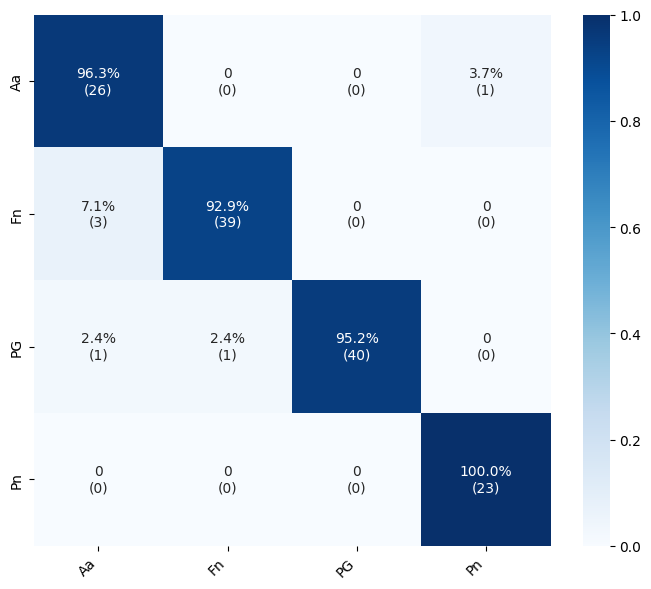

All TEST SET results saved to: /content/output_level_1/20260318_053928/level_1_test_result


In [16]:
import os
import json
import re
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, recall_score
)

from raman.config_io import load_experiment
from raman.data_paths import resolve_dataset_stage
from raman.dataset import RamanDataset
from raman.model import ResNeXt1D_Transformer
from raman.preprocess import InputPreprocessor
from raman.train_utils import mask_logits_by_parent, load_split_files

BASE_DIR = ""
# BASE_DIR = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))


def resolve_path(path):
    if path is None:
        return path
    if os.path.isabs(path):
        return path
    return os.path.abspath(os.path.join(BASE_DIR, path))


def _load_hierarchy_meta(exp_dir):
    meta_path = os.path.join(exp_dir, "hierarchy_meta.json")
    if not os.path.exists(meta_path):
        return None

    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    parent_to_children_raw = meta.get("parent_to_children", {})
    parent_to_children = {}
    for level, mapping in parent_to_children_raw.items():
        parent_to_children[level] = {int(k): list(v) for k, v in mapping.items()}

    parent_models_raw = meta.get("parent_models", {})
    parent_models = {}
    for level, mapping in parent_models_raw.items():
        parent_models[level] = {}
        for k, v in mapping.items():
            entry = dict(v)
            entry["child_ids"] = [int(c) for c in entry.get("child_ids", [])]
            parent_models[level][int(k)] = entry

    meta["parent_to_children"] = parent_to_children
    meta["parent_models"] = parent_models
    meta["level_models"] = meta.get("level_models", {})
    return meta


# =====================
# 实验目录（需要包含多个层级的模型）
# =====================
EXP_DIR = "/content/output_level_1/20260318_053928"
EXP_DIR = resolve_path(EXP_DIR)
config = load_experiment(EXP_DIR)

DATASET_ROOT = os.fspath(
    resolve_dataset_stage(
        resolve_path(config.dataset_root),
        stage="train",
        project_root=BASE_DIR,
        must_exist=True,
    )
)
config.dataset_root = DATASET_ROOT

# 手动设置评估层级
EVAL_LEVEL = "level_1"
INHERIT_MISSING_LEVELS = True  # 缺失层级时向最低级继承（便于展示）

# =====================
# 单模型评估
# - EVAL_ONLY_LEVEL: 只评估某一层级
# - EVAL_ONLY_PARENT: 只评估某个父类下的子模型（父类 id）
# =====================
# EVAL_ONLY_LEVEL = "level_3"
# EVAL_ONLY_PARENT = 2
EVAL_ONLY_LEVEL = None
EVAL_ONLY_PARENT = None

# =====================
# 输出目录
# =====================
RESULT_DIR = os.path.join(EXP_DIR, f"{EVAL_LEVEL}_test_result")
os.makedirs(RESULT_DIR, exist_ok=True)

OUT_CSV = os.path.join(RESULT_DIR, "test_eval_results.csv")
OUT_CM_PNG = os.path.join(RESULT_DIR, "confusion_matrix.png")
OUT_CM_RAW = os.path.join(RESULT_DIR, "confusion_matrix_raw.csv")
OUT_REPORT = os.path.join(RESULT_DIR, "classification_report.txt")


# =====================
# 加载模型（逐层）
# =====================

def resolve_level_order(dataset, target_level):
    # 校验目标层级是否存在
    if target_level is None:
        target_level = (
            getattr(config, "eval_level", None)
            or getattr(config, "train_level", None)
            or "leaf"
        )
    if target_level not in dataset.head_names:
        raise ValueError(
            f"Unknown eval_level: {target_level}. Available: {dataset.head_names}"
        )
    level_order = []
    for name in dataset.head_names:
        level_order.append(name)
        if name == target_level:
            break
    return target_level, level_order


def _effective_label_name(dataset, idx, target_level):
    # 取该样本在指定层级的名称（缺失时退到 leaf）
    if hasattr(dataset, "_resolve_level_name"):
        target_level = dataset._resolve_level_name(target_level)
    hier = dataset.hier_names[idx]
    name = hier.get(target_level)
    if name is None:
        name = hier.get("leaf")
    return name


def _pred_id_to_name(dataset, level_name, pred_id):
    level_idx = dataset.head_name_to_idx[level_name]
    return dataset.inv_label_maps_by_level[level_idx].get(int(pred_id))


def _build_display_classes(dataset, eval_level, parent_models):
    # 构建“展示用”的类别：有下一层就展开，没有就保留父类
    eval_idx = dataset.head_name_to_idx[eval_level]
    parent_level = dataset.get_parent_level(eval_level)
    if parent_level is None:
        return list(dataset.class_names_by_level[eval_idx])

    parent_idx = dataset.head_name_to_idx[parent_level]
    parent_names = dataset.class_names_by_level[parent_idx]
    parent_label_map = dataset.label_maps_by_level[parent_idx]
    child_inv = dataset.inv_label_maps_by_level[eval_idx]
    children_by_parent = dataset.parent_to_children.get(eval_level, {})
    parent_entries = parent_models.get(eval_level, {})

    classes = []
    for parent_name in parent_names:
        parent_id = parent_label_map.get(parent_name)
        child_ids = children_by_parent.get(parent_id)
        entry = parent_entries.get(parent_id)
        has_model = entry is not None and entry.get("model_path") is not None

        if child_ids and (has_model or len(child_ids) == 1):
            for cid in child_ids:
                child_name = child_inv.get(int(cid))
                if child_name is not None:
                    classes.append(child_name)
        else:
            classes.append(parent_name)

    return classes


def _sample_effective_level(dataset, idx, target_level):
    # 找到该样本最深的有效层级（用于继承）
    level = target_level
    while True:
        level_idx = dataset.head_name_to_idx[level]
        if dataset.level_labels[idx, level_idx] >= 0:
            return level
        parent = dataset.get_parent_level(level)
        if parent is None:
            return level
        level = parent


# =====================
# 测试集评估
# =====================

def evaluate_test_set():
    use_cuda = (config.use_gpu and torch.cuda.is_available())
    device = torch.device("cuda" if use_cuda else "cpu")
    print(
        f"Using: {device} (config.use_gpu={config.use_gpu}, "
        f"cuda_available={torch.cuda.is_available()})"
    )

    # 数据集
    dataset = RamanDataset(DATASET_ROOT, augment=False, config=config)

    eval_level = EVAL_ONLY_LEVEL or EVAL_LEVEL
    eval_level, level_order = resolve_level_order(dataset, eval_level)
    eval_idx = dataset.head_name_to_idx[eval_level]

    labels = dataset.level_labels[:, eval_idx]
    inv_label_map = dataset.inv_label_maps_by_level[eval_idx]

    # evaluate 阶段，优先使用保存的切分清单
    split = load_split_files(dataset, EXP_DIR)
    if split is not None:
        _, test_idx = split
    else:
        # fallback: 按 split_level 切分
        split_level = getattr(config, "split_level", None) or "leaf"
        group_keys = [
            dataset.get_split_key(i, split_level)
            for i in range(len(dataset))
        ]

        group_to_indices = defaultdict(list)
        for idx, k in enumerate(group_keys):
            group_to_indices[k].append(idx)

        rng = np.random.RandomState(seed=config.seed)

        test_idx = []
        for _, idxs in group_to_indices.items():
            idxs = list(idxs)
            rng.shuffle(idxs)

            n = len(idxs)
            n_train = int(round(n * config.train_split))
            if n == 1:
                continue

            n_train = max(1, min(n - 1, n_train))
            test_idx.extend(idxs[n_train:])

        test_idx = np.array(sorted(test_idx))

    print(f"\n[Test Split] Test samples: {len(test_idx)}")

    # 模型
    meta = _load_hierarchy_meta(EXP_DIR) or {}
    parent_models = meta.get("parent_models", {})
    parent_to_children = meta.get("parent_to_children", dataset.parent_to_children)
    level_models_meta = meta.get("level_models", {})

    level_model_paths = {}

    def _build_parent_models_from_files(level):
        mapping = {}
        for parent_idx, child_ids in parent_to_children.get(level, {}).items():
            mapping[int(parent_idx)] = {"model_path": None, "child_ids": list(child_ids)}

        pattern = re.compile(rf"^{re.escape(level)}_parent_(\d+)_model\.pt$")
        for name in os.listdir(EXP_DIR):
            m = pattern.match(name)
            if not m:
                continue
            parent_idx = int(m.group(1))
            entry = mapping.get(parent_idx, {"child_ids": []})
            entry["model_path"] = name
            mapping[parent_idx] = entry

        return mapping

    for level in level_order:
        model_name = level_models_meta.get(level, f"{level}_model.pt")
        level_model_paths[level] = os.path.join(EXP_DIR, model_name)

    for level in level_order:
        if os.path.exists(level_model_paths[level]):
            continue
        if parent_models.get(level):
            continue
        built = _build_parent_models_from_files(level)
        if built:
            parent_models[level] = built

    # 额外补全 eval_level 的 parent 模型
    built = _build_parent_models_from_files(eval_level)
    if built:
        if eval_level not in parent_models or not parent_models.get(eval_level):
            parent_models[eval_level] = built
        else:
            parent_models[eval_level].update(built)

    if INHERIT_MISSING_LEVELS:
        classes = _build_display_classes(dataset, eval_level, parent_models)
        num_classes = len(classes)
        train_name_to_idx = {name: i for i, name in enumerate(classes)}
    else:
        # 使用训练时的类顺序作为评估坐标系
        train_class_names_by_level = meta.get("class_names_by_level", {})
        classes = None
        if isinstance(train_class_names_by_level, dict):
            classes = train_class_names_by_level.get(eval_level)
        if not classes:
            classes = [inv_label_map[i] for i in range(dataset.num_classes_by_level[eval_level])]
        num_classes = len(classes)
        train_name_to_idx = {name: i for i, name in enumerate(classes)}

    # 单模型选择
    target_parent_idx = None
    if EVAL_ONLY_PARENT is not None:
        target_parent_idx = int(EVAL_ONLY_PARENT)

    if target_parent_idx is not None:
        built = _build_parent_models_from_files(eval_level)
        if eval_level not in parent_models or not parent_models.get(eval_level):
            parent_models[eval_level] = built or {}
        elif built:
            parent_models[eval_level].update(built)

        pm = parent_models.get(eval_level, {})
        entry = pm.get(target_parent_idx)
        if not entry or entry.get("model_path") is None:
            raise FileNotFoundError(
                f"No parent model for {eval_level}, parent={target_parent_idx}"
            )
        parent_models[eval_level] = {target_parent_idx: entry}

        child_ids = entry.get("child_ids", [])
        if child_ids and (entry.get("model_path") is not None or len(child_ids) == 1):
            allowed_names = [inv_label_map[i] for i in child_ids]
        else:
            parent_level_name = dataset.get_parent_level(eval_level)
            parent_inv = None
            if parent_level_name is not None:
                parent_idx = dataset.head_name_to_idx[parent_level_name]
                parent_inv = dataset.inv_label_maps_by_level[parent_idx]
            allowed_names = []
            if parent_inv is not None:
                parent_name = parent_inv.get(int(target_parent_idx))
                if parent_name is not None:
                    allowed_names = [parent_name]
        classes = [c for c in classes if c in allowed_names]
        num_classes = len(classes)
        train_name_to_idx = {name: i for i, name in enumerate(classes)}

    print(f"\n[Evaluate] level = {eval_level}, num_classes = {num_classes}")
    print("[Evaluate] Label Mapping (train order):")
    for i in range(num_classes):
        print(f"{i:2d} -> {classes[i]}")

    level_model_cache = {}
    parent_model_cache = {}

    def get_level_model(level):
        if level in level_model_cache:
            return level_model_cache[level]

        num = dataset.num_classes_by_level[level]
        model = ResNeXt1D_Transformer(num_classes=num, config=config).to(device)

        model_path = level_model_paths.get(level)
        if not model_path or not os.path.exists(model_path):
            raise FileNotFoundError(
                f"Model not found for level '{level}': {model_path}"
            )

        state = torch.load(model_path, map_location=device)
        model.load_state_dict(state)
        model.eval()
        level_model_cache[level] = model
        return model

    def get_parent_model(level, parent_idx, child_ids, model_path):
        key = (level, parent_idx)
        if key in parent_model_cache:
            return parent_model_cache[key]

        full_path = model_path
        if not os.path.isabs(full_path):
            full_path = os.path.join(EXP_DIR, model_path)

        if not os.path.exists(full_path):
            raise FileNotFoundError(
                f"Parent model not found: {full_path}"
            )

        model = ResNeXt1D_Transformer(num_classes=len(child_ids), config=config).to(device)

        state = torch.load(full_path, map_location=device)
        model.load_state_dict(state)
        model.eval()
        parent_model_cache[key] = model
        return model

    def _map_pred_to_display(pred_level, pred_id, x):
        # 预测落在父层时，如果该父层有子模型，则继续下探
        if pred_id < 0:
            return None
        if pred_level == eval_level:
            return (pred_level, pred_id)

        parent_level = dataset.get_parent_level(eval_level)
        if parent_level is None or pred_level != parent_level:
            return (pred_level, pred_id)

        entry = parent_models.get(eval_level, {}).get(int(pred_id))
        if entry is None:
            return (pred_level, pred_id)

        child_ids = entry.get("child_ids", [])
        model_path = entry.get("model_path")
        if not child_ids:
            return (pred_level, pred_id)

        if model_path is None:
            if len(child_ids) == 1:
                return (eval_level, child_ids[0])
            return (pred_level, pred_id)

        logits = get_parent_model(eval_level, int(pred_id), child_ids, model_path)(x)
        pred_local = logits.argmax(1).item()
        pred_global = child_ids[pred_local]
        return (eval_level, pred_global)

    def predict_up_to_level(x, target_level):
        parent_pred = None

        for level in level_order:
            if parent_pred is None:
                logits = get_level_model(level)(x)
                pred_global = logits.argmax(1).item()
            else:
                parent_idx = int(parent_pred)
                if level in parent_models and parent_models[level]:
                    entry = parent_models[level].get(parent_idx)
                    if entry is None:
                        return -1
                    child_ids = entry.get("child_ids", [])
                    model_path = entry.get("model_path")
                    if model_path is None:
                        if len(child_ids) == 1:
                            pred_global = child_ids[0]
                        else:
                            return -1
                    else:
                        logits = get_parent_model(level, parent_idx, child_ids, model_path)(x)
                        pred_local = logits.argmax(1).item()
                        pred_global = child_ids[pred_local]
                else:
                    logits = get_level_model(level)(x)
                    if level in parent_to_children:
                        logits, valid_parent = mask_logits_by_parent(
                            logits,
                            torch.tensor([parent_pred], device=device),
                            parent_to_children[level]
                        )
                        if not valid_parent.any():
                            return -1
                    pred_global = logits.argmax(1).item()

            if level == target_level:
                return pred_global

            parent_pred = pred_global

        return -1

    # 输入预处理
    preprocessor = InputPreprocessor(config, device)

    all_preds, all_labels, all_paths = [], [], []
    skipped = 0
    invalid_pred = 0

    print("\n>>> Running TEST SET evaluation\n")

    parent_level_for_eval = dataset.get_parent_level(eval_level)

    for i in test_idx:
        sample_level = eval_level
        if INHERIT_MISSING_LEVELS:
            sample_level = _sample_effective_level(dataset, i, eval_level)
            true_name = _effective_label_name(dataset, i, sample_level)
            if true_name is None:
                skipped += 1
                continue
            if true_name not in train_name_to_idx:
                skipped += 1
                continue
            true_label_mapped = train_name_to_idx[true_name]
        else:
            true_label = labels[i]
            if true_label < 0:
                skipped += 1
                continue

            true_name = inv_label_map.get(int(true_label))
            if true_name not in train_name_to_idx:
                skipped += 1
                continue
            true_label_mapped = train_name_to_idx[true_name]

        if EVAL_ONLY_PARENT is not None and parent_level_for_eval is not None:
            parent_label = dataset.level_labels[i, dataset.head_name_to_idx[parent_level_for_eval]]
            if parent_label < 0 or int(parent_label) != int(EVAL_ONLY_PARENT):
                invalid_pred += 1
                continue

        path = dataset.samples[i]
        X = preprocessor(path)

        with torch.no_grad():
            pred = predict_up_to_level(X, sample_level)

        # pred 是“全局 class id”
        if INHERIT_MISSING_LEVELS:
            mapped = _map_pred_to_display(sample_level, pred, X)
            if mapped is None:
                invalid_pred += 1
                continue
            pred_level_name, pred_id = mapped
            pred_name = _pred_id_to_name(dataset, pred_level_name, pred_id)
        else:
            pred_name = inv_label_map.get(int(pred))
        if pred_name not in train_name_to_idx:
            invalid_pred += 1
            continue
        pred_mapped = train_name_to_idx[pred_name]

        all_preds.append(pred_mapped)
        all_labels.append(true_label_mapped)
        all_paths.append(path)

    if not all_labels:
        print("No valid samples for this level.")
        return

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 指标
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels, all_preds,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )
    macro_recall = recall_score(
        all_labels, all_preds,
        average="macro",
        labels=list(range(num_classes)),
        zero_division=0
    )

    print("\n=====================================")
    print(f" Test Set Accuracy: {acc * 100:.4f}%")
    print(f" Macro F1-score:    {macro_f1 * 100:.4f}%")
    print(f" Macro Recall:      {macro_recall * 100:.4f}%")
    print("=====================================\n")

    # 报告
    report = classification_report(
        all_labels, all_preds,
        target_names=classes,
        labels=list(range(num_classes)),
        output_dict=True,
        zero_division=0
    )

    def _fmt_line(name, p, r, f1, support):
        return (
            f"{name:<20}"
            f"{p * 100:>12.4f}%"
            f"{r * 100:>12.4f}%"
            f"{f1 * 100:>12.4f}%"
            f"{int(round(support)):>12d}"
        )

    report_lines = []
    report_lines.append(
        f"{'':<20}{'precision':>12}{'recall':>12}{'f1-score':>12}{'support':>12}"
    )
    report_lines.append("")

    for cls_name in classes:
        row = report[cls_name]
        report_lines.append(
            _fmt_line(
                cls_name,
                row["precision"],
                row["recall"],
                row["f1-score"],
                row["support"],
            )
        )

    total_support = int(sum(report[name]["support"] for name in classes))
    report_lines.append("")
    report_lines.append(
        f"{'accuracy':<20}{'':>12}{'':>12}{acc * 100:>11.4f}%{total_support:>12d}"
    )

    macro = report["macro avg"]
    weighted = report["weighted avg"]
    report_lines.append(
        _fmt_line(
            "macro avg",
            macro["precision"],
            macro["recall"],
            macro["f1-score"],
            macro["support"],
        )
    )
    report_lines.append(
        _fmt_line(
            "weighted avg",
            weighted["precision"],
            weighted["recall"],
            weighted["f1-score"],
            weighted["support"],
        )
    )

    with open(OUT_REPORT, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))

    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    denom = cm.sum(axis=1, keepdims=True).astype(np.float32)
    denom[denom == 0] = 1.0
    cm_norm = cm.astype(np.float32) / denom

    pd.DataFrame(cm, index=classes, columns=classes).to_csv(OUT_CM_RAW)

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] == 0:
                annot[i, j] = "0\n(0)"
            else:
                annot[i, j] = f"{cm_norm[i, j] * 100:.1f}%\n({cm[i, j]})"

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm_norm,
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        annot=annot,
        fmt="",
        annot_kws={"size": 10}
    )
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_CM_PNG, dpi=300)
    plt.show()
    plt.close()

    # 单样本明细
    df = pd.DataFrame({
        "path": all_paths,
        "label_true": all_labels,
        "label_pred": all_preds
    })
    df.to_csv(OUT_CSV, index=False)

    print("All TEST SET results saved to:", RESULT_DIR)


if __name__ == "__main__":
    evaluate_test_set()


In [17]:
import os
import shutil

def zip_folder_here(src_dir):
    """
    将 src_dir 压缩成 zip：
    - zip 名称 = 文件夹名
    - zip 位置 = 当前 py 文件所在目录
    """
    # 目标文件夹绝对路径
    src_dir = os.path.abspath(src_dir)

    # 当前 py 文件所在目录
    # cur_dir = os.path.dirname(os.path.abspath(__file__))
    cur_dir = ""

    # 文件夹名
    folder_name = os.path.basename(src_dir.rstrip("/"))

    # make_archive 的 base_name（不带 .zip）
    base_name = os.path.join(cur_dir, folder_name)

    shutil.make_archive(
        base_name=base_name,
        format="zip",
        root_dir=os.path.dirname(src_dir),
        base_dir=folder_name
    )

    print(f"压缩完成：{base_name}.zip")

zip_folder_here("/content/output_level_1/20260318_053928")


压缩完成：20260318_053928.zip


In [ ]:
importlib.reload(ac)


<module 'analysis_core' from '/content/analysis_core.py'>

In [ ]:
import analysis_core as ac


# ---------------- 手动配置 ----------------
EXP_DIR = "/content/output/20260204_161119"  # 训练输出目录（含模型与层级元数据）
ANALYSIS_LEVEL = "level_1"              # 分析层级（None 时用 config.train_level）
PARENT_IDX = None                       # 指定父类 id 或 "all"；None 表示默认/自动
USE_TRAIN_AUG = False                   # 是否使用训练增强来构建分析数据

HEATMAP_NUM_BATCHES = 10                # 采样多少个 batch 计算热图
HEATMAP_STEPS = 32                      # IG 积分步数（越大越稳但更慢）
HEATMAP_MAX_PER_CLASS = 50              # 每类最多使用的样本数上限
HEATMAP_TARGET_MODE = "true"            # true=真实标签，pred=预测标签
HEATMAP_ROW_NORM = "max"                # 行归一化方式：max / sum / none
HEATMAP_USE_TRAIN_LOADER = True         # True 用训练集，False 用测试集
HEATMAP_TOPK_PER_CLASS = 5              # 每类导出 top-k 波段
INHERIT_MISSING_LEVELS = True           # 缺失层级时向最低级继承（便于展示）


def main():
    heatmap_cfg = ac.HeatmapConfig(
        num_batches=HEATMAP_NUM_BATCHES,
        steps=HEATMAP_STEPS,
        max_per_class=HEATMAP_MAX_PER_CLASS,
        target_mode=HEATMAP_TARGET_MODE,
        row_norm=HEATMAP_ROW_NORM,
        use_train_loader=HEATMAP_USE_TRAIN_LOADER,
        topk_per_class=HEATMAP_TOPK_PER_CLASS,
    )
    ac.run_single_pipeline(
        EXP_DIR,
        ANALYSIS_LEVEL,
        PARENT_IDX,
        use_train_aug=USE_TRAIN_AUG,
        heatmap_cfg=heatmap_cfg,
        inherit_missing_levels=INHERIT_MISSING_LEVELS,
    )


if __name__ == "__main__":
    main()


In [ ]:
import analysis_core as ac


# ---------------- 手动配置 ----------------
EXP_DIR = "/content/output/20260204_161119"  # 训练输出目录（含模型与层级元数据）
ANALYSIS_LEVEL = "level_2"              # 分析层级（聚合通常是 level_2）
PARENT_IDX = "all"                      # 参与聚合的 parent：all / 指定 id / None
USE_TRAIN_AUG = False                   # 是否使用训练增强来构建分析数据

HEATMAP_NUM_BATCHES = 10                # 采样多少个 batch 计算热图
HEATMAP_STEPS = 32                      # IG 积分步数（越大越稳但更慢）
HEATMAP_MAX_PER_CLASS = 50              # 每类最多使用的样本数上限
HEATMAP_TARGET_MODE = "true"            # true=真实标签，pred=预测标签
HEATMAP_ROW_NORM = "max"                # 行归一化方式：max / sum / none
HEATMAP_USE_TRAIN_LOADER = True         # True 用训练集，False 用测试集
HEATMAP_TOPK_PER_CLASS = 5              # 每类导出 top-k 波段
INHERIT_MISSING_LEVELS = True           # 缺失层级时向最低级继承（便于展示）


def main():
    heatmap_cfg = ac.HeatmapConfig(
        num_batches=HEATMAP_NUM_BATCHES,
        steps=HEATMAP_STEPS,
        max_per_class=HEATMAP_MAX_PER_CLASS,
        target_mode=HEATMAP_TARGET_MODE,
        row_norm=HEATMAP_ROW_NORM,
        use_train_loader=HEATMAP_USE_TRAIN_LOADER,
        topk_per_class=HEATMAP_TOPK_PER_CLASS,
    )
    ac.run_aggregate_pipeline(
        EXP_DIR,
        ANALYSIS_LEVEL,
        PARENT_IDX,
        use_train_aug=USE_TRAIN_AUG,
        heatmap_cfg=heatmap_cfg,
        inherit_missing_levels=INHERIT_MISSING_LEVELS,
        fallback_to_single=True,
    )


if __name__ == "__main__":
    main()


In [6]:
from pathlib import Path
import shutil
import sys

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from dataset_process.cli import ensure_dataset_layout
from dataset_process.pipeline import pack_dataset_init, unpack_dataset_init
from dataset_process.profiles import get_profile

DATASET_NAME = "厌氧菌"
profile = get_profile(DATASET_NAME)
dataset_dir = ensure_dataset_layout(profile)
pack_path = dataset_dir / profile.root_init_pack
init_dir = dataset_dir / profile.root_init

USE_COLAB_UPLOAD = False
RUN_UNPACK_INIT = pack_path.exists()
RUN_PACK_INIT = False
CLEAR_INIT_BEFORE_UNPACK = False

if USE_COLAB_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        uploaded_name = next(iter(uploaded))
        shutil.move(uploaded_name, pack_path)
        RUN_UNPACK_INIT = True
        print(f"Uploaded packed file -> {pack_path}")

if RUN_UNPACK_INIT:
    if not pack_path.exists():
        raise FileNotFoundError(f"Missing packed file: {pack_path}")
    if CLEAR_INIT_BEFORE_UNPACK and init_dir.exists():
        shutil.rmtree(init_dir)
        init_dir.mkdir(parents=True, exist_ok=True)
    unpack_dataset_init(pack_path, init_dir)

if RUN_PACK_INIT:
    if not init_dir.exists():
        raise FileNotFoundError(f"Missing init dir: {init_dir}")
    pack_dataset_init(init_dir, pack_path)

print(f"dataset_dir = {dataset_dir}")
print(f"packed file = {pack_path}")
print(f"dataset_init = {init_dir}")


[Unpack] samples=703, restored=/content/dataset/厌氧菌/dataset_init
dataset_dir = /content/dataset/厌氧菌
packed file = /content/dataset/厌氧菌/dataset_init.npz
dataset_init = /content/dataset/厌氧菌/dataset_init


In [11]:
from pathlib import Path
import shutil
import sys

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from dataset_process.cli import ensure_dataset_layout
from dataset_process.pipeline import classify_dataset, preprocess_test_dataset, preprocess_train_dataset
from dataset_process.profiles import get_profile

DATASET_NAME = "厌氧菌"
profile = get_profile(DATASET_NAME)
dataset_dir = ensure_dataset_layout(profile)

RUN_CLASSIFY = True
RUN_PREPROCESS_TRAIN = True
RUN_PREPROCESS_TEST = False
REBUILD_RAW = False
REBUILD_TRAIN = False
REBUILD_TEST = False

raw_dir = dataset_dir / profile.root_process_raw
train_dir = dataset_dir / profile.root_train_clean
train_fig_dir = dataset_dir / profile.root_train_fig
test_dir = dataset_dir / profile.root_test_clean
test_fig_dir = dataset_dir / profile.root_test_fig


def reset_dir(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

if RUN_CLASSIFY:
    if REBUILD_RAW:
        reset_dir(raw_dir)
    classify_dataset(profile, dataset_dir)

if RUN_PREPROCESS_TRAIN:
    if REBUILD_TRAIN:
        reset_dir(train_dir)
        reset_dir(train_fig_dir)
    preprocess_train_dataset(profile, dataset_dir)

if RUN_PREPROCESS_TEST:
    if REBUILD_TEST:
        reset_dir(test_dir)
        reset_dir(test_fig_dir)
    preprocess_test_dataset(profile, dataset_dir)

print(f"dataset_raw = {raw_dir}")
print(f"dataset_train = {train_dir}")
print(f"dataset_test = {test_dir}")


Stage 1 complete: copied 703 files into /content/dataset/厌氧菌/dataset_raw

=== Processing: Aa ===
  PCA outlier removal: k=48, threshold=342.812866, removed=8
  Mean spectrum saved: /content/dataset/厌氧菌/dataset_train_fig/Aa.png

=== Processing: Fn ===
  PCA outlier removal: k=8, threshold=508.069519, removed=11
  Mean spectrum saved: /content/dataset/厌氧菌/dataset_train_fig/Fn.png

=== Processing: PG ===
  PCA outlier removal: k=39, threshold=435.490051, removed=11
  Mean spectrum saved: /content/dataset/厌氧菌/dataset_train_fig/PG.png

=== Processing: Pn ===
  PCA outlier removal: k=5, threshold=364.254456, removed=6
  Mean spectrum saved: /content/dataset/厌氧菌/dataset_train_fig/Pn.png

Training dataset preprocessing finished:
- Clean spectra: /content/dataset/厌氧菌/dataset_train
- Mean plots: /content/dataset/厌氧菌/dataset_train_fig
dataset_raw = /content/dataset/厌氧菌/dataset_raw
dataset_train = /content/dataset/厌氧菌/dataset_train
dataset_test = /content/dataset/厌氧菌/dataset_test


In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from dataset_process.cli import ensure_dataset_layout
from dataset_process.pipeline import count_dataset, print_results
from dataset_process.profiles import get_profile

DATASET_NAME = "厌氧菌"
COUNT_SUBDIR = "dataset_train"

profile = get_profile(DATASET_NAME)
dataset_dir = ensure_dataset_layout(profile)
target_dir = dataset_dir / COUNT_SUBDIR

tree, total_files = count_dataset(target_dir)
print_results(tree, total_files)



================ 数据集统计 ================

总文件数: 667

Aa: 135 个文件

Fn: 208 个文件

PG: 210 个文件

Pn: 114 个文件


